In [1]:
import qiskit
print(qiskit.__version__)

1.3.2


# AML23703 – Quantum Computing

# Tutorial 3: Single-Qubit Quantum Gates

---

**Name:** Mythri M R

**USN:** 1GA23AI027

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 06-08-2026

# Aim

To implement and analyze the behavior of single-qubit quantum gates using Qiskit and visualize the resulting quantum states.

# Theory 

Quantum gates are reversible unitary operators that manipulate qubits.

Unlike classical logic gates, quantum gates preserve probability amplitudes and may introduce phase changes.

The important single-qubit gates are

- Pauli-X
- Pauli-Y
- Pauli-Z
- Hadamard
- Phase Gates (S,T)

These gates form the foundation of quantum algorithms.

## Gate Summary

| Gate | Symbol | Purpose |
|------|--------|---------|
| Pauli-X | X | Bit Flip |
| Pauli-Y | Y | Bit + Phase Flip |
| Pauli-Z | Z | Phase Flip |
| Hadamard | H | Creates Superposition |
| Phase | S | Phase Rotation |
| T Gate | T | π/4 Phase Rotation |

# Required Libraries

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_city,
    plot_histogram
)
from qiskit_aer import AerSimulator

import matplotlib.pyplot as plt
import numpy as np

# Exercise 1 Easy

## Implementing Pauli-X, Pauli-Y and Pauli-Z Gates

### Pauli-X Gate

The Pauli-X gate flips the qubit from |0⟩ to |1⟩.
### Matrix Representation

$$
X =
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$

Quantum Circuit


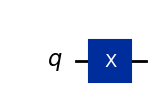

State Vector
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

Bloch Sphere


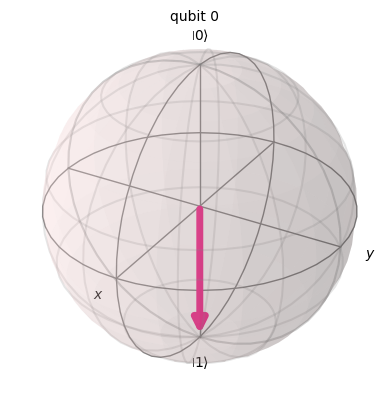

In [43]:
qc_x = QuantumCircuit(1)
qc_x.x(0)

print("Quantum Circuit")
display(qc_x.draw("mpl"))

state_x = Statevector.from_instruction(qc_x)

print("State Vector")
print(state_x)

print("\nBloch Sphere")
display(plot_bloch_multivector(state_x))

## Observation
The Pauli-X gate flips the qubit from the |0⟩ state to the |1⟩ state.
The Bloch Sphere shows the qubit moving from the north pole to the south pole,
indicating a complete bit flip.

### Pauli-Y Gate

The Pauli-Y gate performs a bit flip together with a phase change.

Matrix Representation

$$
Y=
\begin{bmatrix}
0&-i\\
i&0
\end{bmatrix}
$$

Quantum Circuit


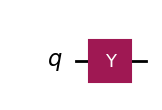

State Vector
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))

Bloch Sphere


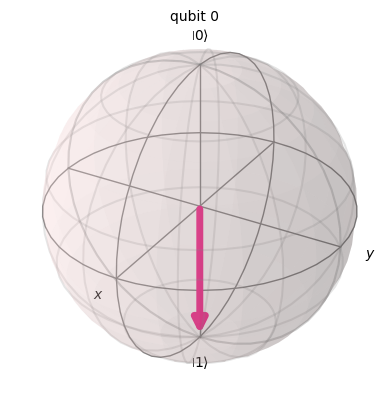

In [44]:
qc_y = QuantumCircuit(1)
qc_y.y(0)

print("Quantum Circuit")
display(qc_y.draw("mpl"))

state_y = Statevector.from_instruction(qc_y)

print("State Vector")
print(state_y)

print("\nBloch Sphere")
display(plot_bloch_multivector(state_y))

## Observation

The Pauli-Y gate changes both the state and the phase of the qubit.
Although the measurement probabilities remain unchanged, the phase difference
plays an important role in quantum computations.

### Pauli-Z Gate

The Pauli-Z gate changes the phase of the |1⟩ state without changing the
measurement probabilities.

To observe the phase change clearly, a Hadamard gate is applied first.

Matrix Representation

$$
Z=
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}
$$

Quantum Circuit


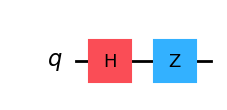

State Vector
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Probability Distribution
|0⟩: 0.50
|1⟩: 0.50


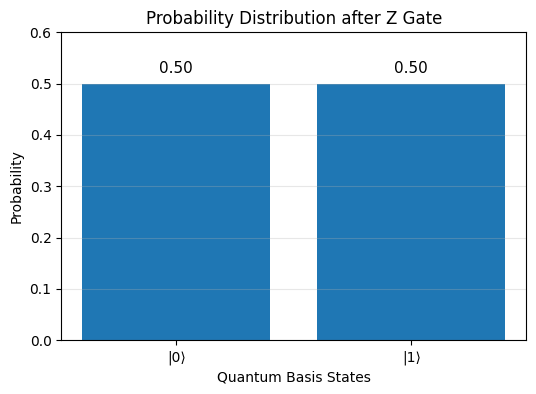

Bloch Sphere


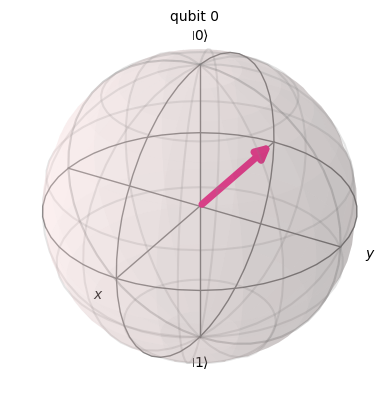

In [53]:
qc_z = QuantumCircuit(1)

# Apply Hadamard first to observe the phase change
qc_z.h(0)
qc_z.z(0)
print("Quantum Circuit")
display(qc_z.draw("mpl"))

state_z = Statevector.from_instruction(qc_z)
print("State Vector")
print(state_z)

# Probability Distribution
probabilities = np.abs(state_z.data)**2
print("\nProbability Distribution")
for state, prob in zip(["|0⟩","|1⟩"], probabilities):
    print(f"{state}: {prob:.2f}")

# Probability Bar Chart
states = ["|0⟩","|1⟩"]
plt.figure(figsize=(6,4))
bars = plt.bar(states, probabilities)
plt.title("Probability Distribution after Z Gate")
plt.xlabel("Quantum Basis States")
plt.ylabel("Probability")
plt.ylim(0,0.6)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.02,
             f"{y:.2f}",
             ha='center',
             fontsize=11)
plt.show()

print("Bloch Sphere")
display(plot_bloch_multivector(state_z))

## Observation

The Pauli-Z gate changes only the phase of the quantum state.
The probability distribution remains unchanged, while the Bloch Sphere
illustrates the phase transformation introduced by the gate.

# Exercise 2 Medium

## Constructing the |−⟩ State using Hadamard and Pauli-Z Gates



To create the |−⟩ (minus) state by applying the Hadamard and Pauli-Z gates on a single qubit and verify the resulting quantum state using simulation andvisualization.

### Theory

The Hadamard gate creates an equal superposition of the |0⟩ and |1⟩ states.

$$
H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

Applying the Pauli-Z gate changes the phase of the |1⟩ component.

$$
Z\left(\frac{|0\rangle+|1\rangle}{\sqrt2}\right)
=
\frac{|0\rangle-|1\rangle}{\sqrt2}
$$

The resulting state is called the **Minus State (|−⟩)**.

Quantum Circuit


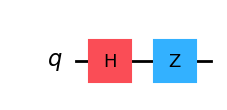

State Vector
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Probability Distribution
|0⟩: 0.50
|1⟩: 0.50


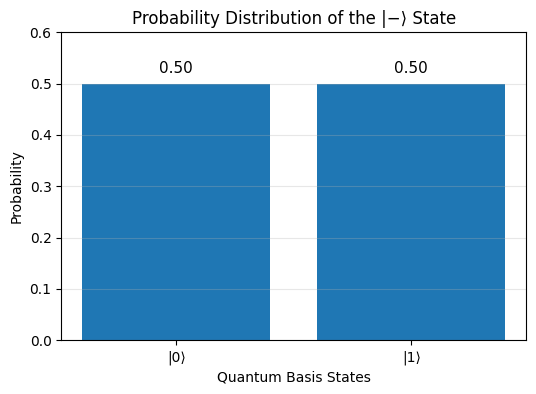


Bloch Sphere Representation


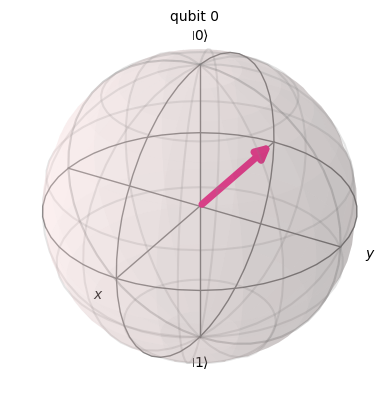

In [54]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_qsphere
)
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

qc2 = QuantumCircuit(1)
qc2.h(0)
qc2.z(0)

print("Quantum Circuit")
display(qc2.draw("mpl"))

state2 = Statevector.from_instruction(qc2)
print("State Vector")
print(state2)

probabilities = np.abs(state2.data)**2
print("\nProbability Distribution")
for state, prob in zip(["|0⟩","|1⟩"], probabilities):
    print(f"{state}: {prob:.2f}")
states = ["|0⟩","|1⟩"]
plt.figure(figsize=(6,4))
bars = plt.bar(states, probabilities)

plt.title("Probability Distribution of the |−⟩ State")
plt.xlabel("Quantum Basis States")
plt.ylabel("Probability")
plt.ylim(0,0.6)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.02,
             f"{y:.2f}",
             ha='center',
             fontsize=11)

plt.show()

print("\nBloch Sphere Representation")
fig = plot_bloch_multivector(state2)
display(fig)

## Observation

The Hadamard gate first created an equal superposition of the |0⟩ and |1⟩ states.
The Pauli-Z gate then introduced a phase shift to the |1⟩ component, resulting
in the |−⟩ state.

The probability distribution remains equal for both basis states, while the
Bloch Sphere clearly illustrates the phase difference introduced by
the Pauli-Z gate.

# Exercise 3 Hard

## Sequence of Five Single-Qubit Gates



To build a quantum circuit using five single-qubit gates, predict the final
quantum state analytically, and verify the result using Qiskit simulation.

### Analytical Gate Sequence

Initial State

$
|0\rangle
$

↓

Hadamard (H)

↓

Pauli-X (X)

↓

T Gate

↓

Pauli-Z (Z)

↓

Pauli-Y (Y)

↓

Final Quantum State

Quantum Circuit


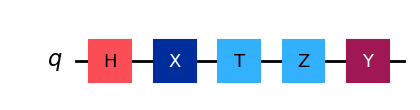


Final State Vector
Statevector([-0.5+0.5j       ,  0. +0.70710678j],
            dims=(2,))

Probability Distribution
|0⟩: 0.500
|1⟩: 0.500


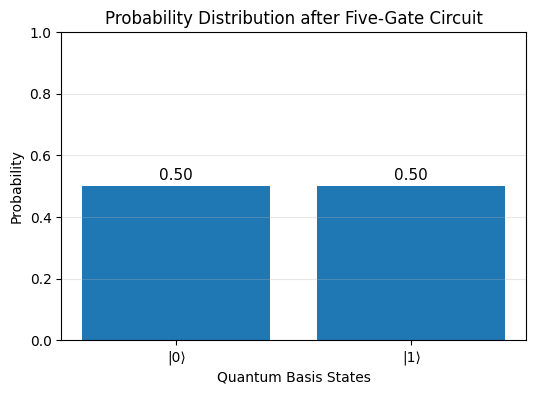


Bloch Sphere Representation


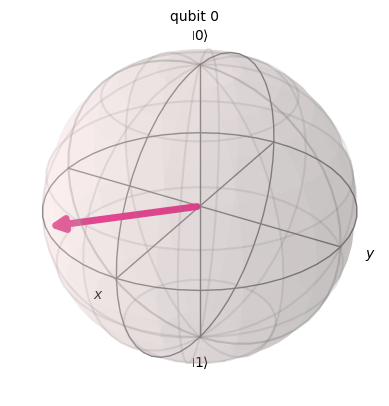

In [55]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_city,
    plot_state_qsphere
)
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

qc3 = QuantumCircuit(1)
# Applying five gates
qc3.h(0)
qc3.x(0)
qc3.t(0)
qc3.z(0)
qc3.y(0)

print("Quantum Circuit")
display(qc3.draw("mpl"))

state3 = Statevector.from_instruction(qc3)
print("\nFinal State Vector")
print(state3)

# Probability Distribution
probabilities = np.abs(state3.data)**2
print("\nProbability Distribution")
for state, prob in zip(["|0⟩","|1⟩"], probabilities):
    print(f"{state}: {prob:.3f}")

# Probability Bar Chart
states = ["|0⟩","|1⟩"]
plt.figure(figsize=(6,4))
bars = plt.bar(states, probabilities)
plt.title("Probability Distribution after Five-Gate Circuit")
plt.xlabel("Quantum Basis States")
plt.ylabel("Probability")
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.02,
             f"{y:.2f}",
             ha='center',
             fontsize=11)
plt.show()

# Bloch Sphere
print("\nBloch Sphere Representation")
display(plot_bloch_multivector(state3))



## Observation

The sequence of five quantum gates transformed the initial qubit into a new
quantum state by combining superposition, bit flips, and phase shifts.

The state vector confirms the final amplitudes of the qubit, while the
probability distribution shows the likelihood of measuring each basis state.

The Bloch Sphere and State City visualizations clearly illustrate the combined
effect of all five gates on the quantum state.

# Exercise 4

## Real World Application – Quantum Coin Flip


To simulate a quantum coin-flip game using a single qubit, measure the outcomes,
and calculate the probability of obtaining Heads and Tails through repeated
simulation.



A classical coin has two possible outcomes: **Heads** or **Tails**.

Similarly, a qubit initialized in the **|0⟩** state can be transformed into an
equal superposition using the Hadamard gate.

$$
H|0\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

When the qubit is measured, there is an equal probability of obtaining **|0⟩**
(Heads) or **|1⟩** (Tails). This behaviour models a fair quantum coin flip.

Quantum Circuit


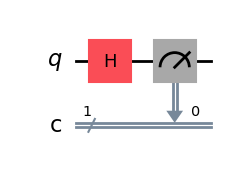


Measurement Counts
{'1': 508, '0': 492}

Results
Heads : 492
Tails : 508

Probability of Heads : 0.492
Probability of Tails : 0.508

Histogram


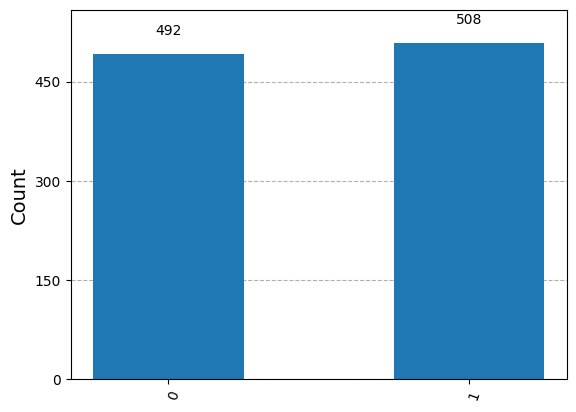

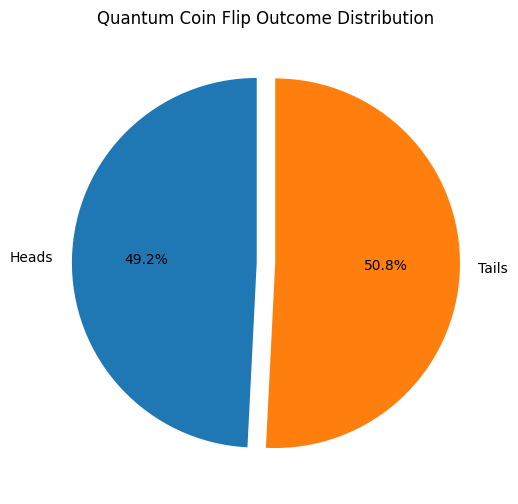

In [58]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt
qc4 = QuantumCircuit(1, 1)
qc4.h(0)
qc4.measure(0, 0)

print("Quantum Circuit")
display(qc4.draw("mpl"))

simulator = AerSimulator()

result = simulator.run(qc4, shots=1000).result()

counts = result.get_counts()

print("\nMeasurement Counts")
print(counts)

# Calculate probabilities
heads = counts.get('0', 0)
tails = counts.get('1', 0)

total = heads + tails

print("\nResults")
print("Heads :", heads)
print("Tails :", tails)

print(f"\nProbability of Heads : {heads/total:.3f}")
print(f"Probability of Tails : {tails/total:.3f}")

# Histogram
print("\nHistogram")
display(plot_histogram(counts))

# Pie Chart of Coin Flip Outcomes
plt.figure(figsize=(6,6))
plt.pie(
    [heads, tails],
    labels=["Heads","Tails"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05,0.05)
)
plt.title("Quantum Coin Flip Outcome Distribution")
plt.show()

## Observation

The Hadamard gate created an equal superposition of the |0⟩ and |1⟩ states.
After performing 1000 measurements, the outcomes for Heads and Tails were
approximately equal, demonstrating the probabilistic nature of quantum
measurement.

The histogram and bar chart show that both outcomes occur with nearly 50%
probability, confirming that the quantum coin behaves like a fair coin.

# Conclusion

In this tutorial, the Pauli-X, Pauli-Y and Pauli-Z gates were successfully implemented and their effects on quantum states were analyzed using Qiskit. The |−⟩ state was created using the Hadamard and Pauli-Z gates, and a sequence of single-qubit gates demonstrated how multiple operations transform a qubit. A quantum coin flip was also simulated to understand the probabilistic nature of quantum measurement. Overall, the tutorial provided a better understanding of single-qubit gates, quantum state transformations, and their practical applications.

# Reflection Questions

### 1. Which gate combination surprised you the most?

The combination of the Hadamard and Pauli-Z gates surprised me the most. Even though the measurement probabilities stayed the same, the phase of the qubit changed and it resulted in a completely different quantum state. This helped me understand that phase plays a very important role in quantum computing.

### 2. How would you explain the Hadamard gate to a classical programmer?

I would explain it by saying that the Hadamard gate is different from anything in classical computing. Instead of making a bit either 0 or 1, it puts a qubit into a superposition where it can represent both states until it is measured. This is one of the main reasons why quantum computers can solve certain problems more efficiently than classical computers.